# Cadence — the Learn phase, in a notebook

**Cadence** runs the synthetic-biology Design → Build → Test → Learn loop with four Claude agents.
The **Learn** agent takes a Test-stage dataset and flags junk, duplicate, and dead columns — each
with a confidence score — before any model is trained.

This notebook reproduces what that agent does, in plain Python, on the bundled sample dataset.
The data-integrity checks are **deterministic and need no API key**; a final optional cell calls the
real Claude agent if `ANTHROPIC_API_KEY` is set.

*Validated against:* Singhal, Allen, Gaddes, Baer & Demirel, *"Biomanufacturability of a Squid Ring
Teeth Protein Library via Orthogonal High-Throughput Screening"* (2026).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../backend'))
import pandas as pd, numpy as np

DATA = '../data/dave-plots/summary_stats.csv'
df = pd.read_csv(DATA)
df

,bin,timepoint_h,n_capillaries,cai_mean,cai_std,fluor_per_od_mean,fluor_per_od_std,dG_dG_cds_only,ra_dG_cds_only,dG_junction,dG_utr_cds30
0,Low,15,17250,0.712,0.041,58.3,22.1,-12.4,-12.4,-3.1,-8.9
1,Medium,15,16980,0.744,0.038,181.6,49.7,-11.9,-11.9,-3.1,-8.7
2,High,15,17110,0.758,0.036,342.8,88.2,-11.6,-11.6,-3.1,-8.6
3,Low,25,17190,0.710,0.043,71.5,27.4,-12.4,-12.4,-3.1,-8.9
4,Medium,25,16905,0.746,0.037,224.9,60.3,-11.9,-11.9,-3.1,-8.7
5,High,25,17040,0.760,0.035,431.2,102.6,-11.6,-11.6,-3.1,-8.6
6,Low,35,17120,0.709,0.044,80.2,31.0,-12.4,-12.4,-3.1,-8.9
7,Medium,35,16880,0.747,0.037,251.3,66.8,-11.9,-11.9,-3.1,-8.7
8,High,35,17000,0.761,0.034,469.7,110.4,-11.6,-11.6,-3.1,-8.6


## 1. What the Learn agent actually sees

The app doesn't hand the model a raw file — it builds a compact text summary (row/column counts,
missing values, value counts for small columns, and the rows inline). That's what the agent reasons
over.

In [2]:
from main import _summarize_dataset   # the app's real summarizer
summary = _summarize_dataset('summary_stats.csv', open(DATA, 'rb').read())
print(summary)

File: summary_stats.csv
Rows: 9, Columns: 11
Column names: bin, timepoint_h, n_capillaries, cai_mean, cai_std, fluor_per_od_mean, fluor_per_od_std, dG_dG_cds_only, ra_dG_cds_only, dG_junction, dG_utr_cds30
Missing values by column:
  (none)
Value counts (low-cardinality columns):
  - bin (3 unique): 'Low'x3, 'Medium'x3, 'High'x3
  - timepoint_h (3 unique): 15x3, 25x3, 35x3
  - n_capillaries (9 unique): 17250x1, 16980x1, 17110x1, 17190x1, 16905x1, 17040x1, 17120x1, 16880x1, 17000x1
  - cai_mean (9 unique): 0.712x1, 0.744x1, 0.758x1, 0.71x1, 0.746x1, 0.76x1, 0.709x1, 0.747x1, 0.761x1
  - cai_std (8 unique): 0.037x2, 0.041x1, 0.036x1, 0.038x1, 0.043x1, 0.035x1, 0.044x1, 0.034x1
  - fluor_per_od_mean (9 unique): 58.3x1, 181.6x1, 342.8x1, 71.5x1, 224.9x1, 431.2x1, 80.2x1, 251.3x1, 469.7x1
  - fluor_per_od_std (9 unique): 22.1x1, 49.7x1, 88.2x1, 27.4x1, 60.3x1, 102.6x1, 31.0x1, 66.8x1, 110.4x1
  - dG_dG_cds_only (3 unique): -12.4x3, -11.9x3, -11.6x3
  - ra_dG_cds_only (3 unique): -12.4x3, -1

## 2. Data-integrity checks (deterministic)

Before trusting any column, the Learn agent asks: is this table even clean? Here are the same three
checks in plain Python, each with a simple confidence score (0–1). On a real run the Claude agent
finds these unprompted; here we compute them directly so the result is reproducible.

In [3]:
flags = []

# (a) malformed, double-prefixed column names  e.g. dG_dG_cds_only
for c in df.columns:
    p = c.split('_')
    if len(p) >= 2 and p[0] == p[1]:
        flags.append((c, 'malformed double-prefixed column name', 0.80))

# (b) exact-duplicate numeric columns (identical values -> correlation 1.000)
num = df.select_dtypes('number')
cols = list(num.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if num[cols[i]].equals(num[cols[j]]):
            r = num[cols[i]].corr(num[cols[j]])
            flags.append((f'{cols[i]} == {cols[j]}', f'exact duplicate column (r = {r:.3f})', 0.80))

# (c) zero-variance 'dead' features (can't contribute to learning)
for c in num.columns:
    if num[c].nunique(dropna=True) <= 1:
        flags.append((c, 'zero-variance "dead" feature', 0.85))

pd.DataFrame(flags, columns=['token', 'issue', 'confidence'])

,token,issue,confidence
0,dG_dG_cds_only,malformed double-prefixed column name,0.80
1,dG_dG_cds_only == ra_dG_cds_only,exact duplicate column (r = 1.000),0.80
2,dG_junction,"zero-variance ""dead"" feature",0.85


## 3. The relationships behind Figures 5–6

Two of the paper's headline findings, drawn from this schema-faithful sample:

1. **Sorting by brightness saturates** — the dim group is clearly lowest, but medium and high look
   similar (in the paper: Cliff's δ +0.46 then −0.03).
2. **Gene spelling tracks protein** — average codon-adaptation index rises with the bin (in the
   paper: R² = 0.91).

Swap in the real per-clone tables (`library_data.xlsx`, `sequence-features-by-bin.xlsx`) to reproduce
the full multivariate result.

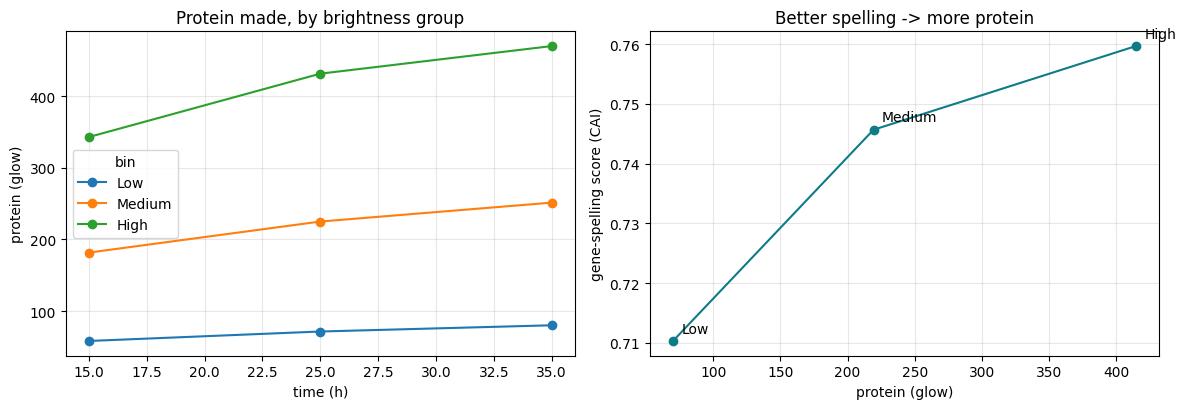

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.facecolor':'white','axes.grid':True,'grid.alpha':0.3})

order = ['Low','Medium','High']

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# (1) protein made by brightness group, over time -> saturation
piv = df.pivot(index='timepoint_h', columns='bin', values='fluor_per_od_mean')[order]
piv.plot(marker='o', ax=ax[0])
ax[0].set_title('Protein made, by brightness group'); ax[0].set_xlabel('time (h)'); ax[0].set_ylabel('protein (glow)')

# (2) gene-spelling score vs protein -> monotonic
g = df.groupby('bin').agg(cai=('cai_mean','mean'), fluor=('fluor_per_od_mean','mean')).reindex(order)
ax[1].plot(g['fluor'], g['cai'], 'o-', color='#0E7C86')
for name, row in g.iterrows():
    ax[1].annotate(name, (row['fluor'], row['cai']), textcoords='offset points', xytext=(6,6))
ax[1].set_title('Better spelling -> more protein'); ax[1].set_xlabel('protein (glow)'); ax[1].set_ylabel('gene-spelling score (CAI)')

plt.tight_layout(); plt.show()

## 4. Optional — run the real Claude Learn agent

If `ANTHROPIC_API_KEY` is set, this calls the actual agent (same code the web app uses). Otherwise a
full captured run is saved at `../results/learn_phase_full_report.txt`.

In [5]:
if os.environ.get('ANTHROPIC_API_KEY'):
    from orchestrator import run_agent
    ctx = _summarize_dataset('summary_stats.csv', open(DATA, 'rb').read())
    out = run_agent('learn',
                    'Analyze this Test dataset; flag undefined/anomalous columns with a confidence index.',
                    dataset_context=ctx)
    print(out['output'][:2500])
else:
    print('No ANTHROPIC_API_KEY set - skipping the live call.')
    print('See ../results/learn_phase_full_report.txt for a full captured run.')

No ANTHROPIC_API_KEY set - skipping the live call.
See ../results/learn_phase_full_report.txt for a full captured run.
